# Phase 5: Explainable AI (XAI) using SHAP

**Goal:** Explain the best performing machine learning model's predictions using SHAP (SHapley Additive exPlanations). We will load the best model, compute global SHAP values on a test sample, generate beeswarm and feature importance plots, and produce human-readable, local explanations (waterfall plots) for 3 individual properties to understand exactly what factors (such as locality premium, connectivity, or size) drove their predicted prices.

In [1]:
# Setup and configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Set random seed for reproducibility
np.random.seed(42)

# Plot saving helper
def save_plot(fig, name, stage):
    folder = f"../outputs/plots/{stage}"
    os.makedirs(folder, exist_ok=True)
    path = f"{folder}/{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")

print("Setup completed successfully.")

Setup completed successfully.


C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Load Best Model & Processed Test Set

We will load the best model (`best_model.pkl`) and the processed test dataset with predictions (`final_test_predictions.csv`).

In [2]:
# Load best model
model_path = '../outputs/models/best_model.pkl'
if not os.path.exists(model_path):
    model_path = 'outputs/models/best_model.pkl'
model = joblib.load(model_path)

# Load processed test dataset
test_path = '../data/processed/final_test_predictions.csv'
if not os.path.exists(test_path):
    test_path = 'data/processed/final_test_predictions.csv'
test_df = pd.read_csv(test_path)

print(f"Best model loaded: {type(model).__name__}")
print(f"Test set loaded. Shape: {test_df.shape}")

Best model loaded: XGBRegressor
Test set loaded. Shape: (50000, 52)


## Step 2: Prepare Data for SHAP

We will separate features and targets, and take a representative sample of **500 rows** to calculate SHAP values. This ensures the calculations run in seconds while providing a robust global explanation.

In [3]:
# Separate features (X) from targets and predictions
target_cols = ['Actual_Price', 'Predicted_Price']
X_test = test_df.drop(columns=target_cols)

# Sample 500 rows for SHAP explanation
X_sample = X_test.sample(500, random_state=42)
print(f"SHAP sample shape: {X_sample.shape}")

SHAP sample shape: (500, 50)


## Step 3: Compute SHAP Values

We will use a generic `shap.Explainer` to automatically select the optimal explainer for our best model, and compute the SHAP values on our test sample.

In [4]:
# Initialize explainer and compute SHAP values
print("Computing SHAP values (this may take a few seconds)...")
explainer = shap.Explainer(model, X_sample)
shap_values = explainer(X_sample)
print("SHAP values computed successfully!")
print("SHAP values shape:", shap_values.shape)

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


Computing SHAP values (this may take a few seconds)...


SHAP values computed successfully!
SHAP values shape: (500, 50)


## Step 4: Global Explainability

We will generate and save two key global explainability plots:
1. **SHAP Summary Plot (Beeswarm)**: Shows the distribution of SHAP values for each feature, illustrating how high/low feature values impact the price.
2. **SHAP Bar Plot**: Shows the mean absolute SHAP value for each feature, representing its global importance.

Saved: ../outputs/plots/shap/shap_beeswarm_summary.png


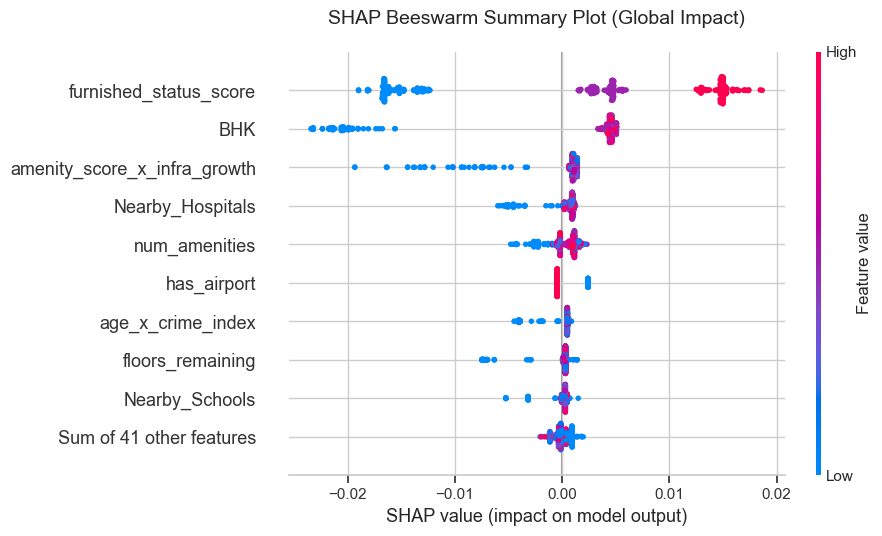

Saved: ../outputs/plots/shap/shap_feature_importance_bar.png


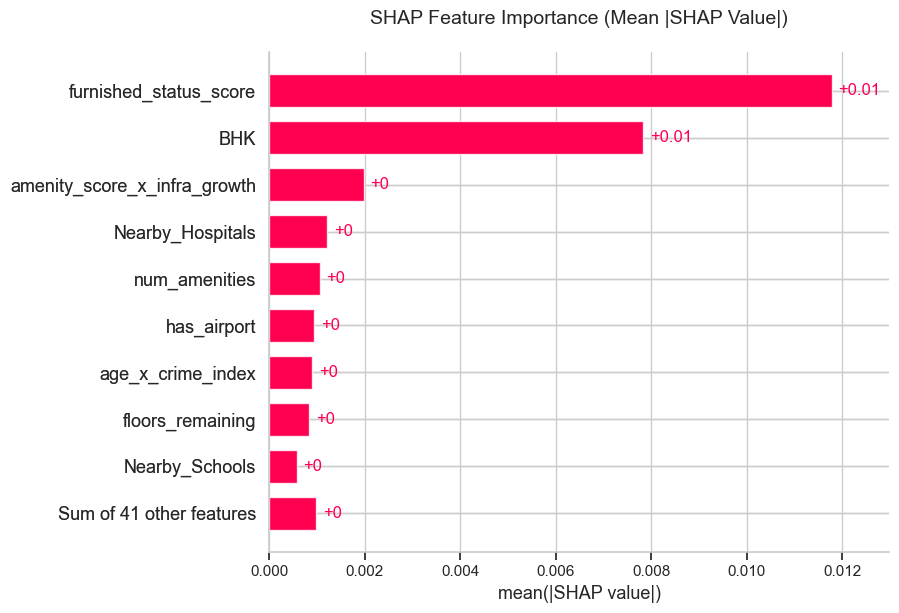

In [5]:
# 1. SHAP Beeswarm Plot
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, show=False)
fig = plt.gcf()
plt.title("SHAP Beeswarm Summary Plot (Global Impact)", fontsize=14, pad=20)
save_plot(fig, "shap_beeswarm_summary", "shap")
plt.show()
plt.close()

# 2. SHAP Bar Plot (Global Feature Importance)
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values, show=False)
fig = plt.gcf()
plt.title("SHAP Feature Importance (Mean |SHAP Value|)", fontsize=14, pad=20)
save_plot(fig, "shap_feature_importance_bar", "shap")
plt.show()
plt.close()

## Step 5: Local Explainability (Waterfall Plots)

We will select **3 individual properties** representing different price segments (Budget, Mid, and Luxury) and generate a SHAP waterfall plot for each. We will also write out a human-readable explanation card for each property detailing why the model predicted its specific price.


=== Local Explanation for Budget Property (Index 14073) ===
Actual Price: 65.33 Lakhs | Predicted Price: 67.83 Lakhs


Saved: ../outputs/plots/shap/shap_waterfall_budget.png


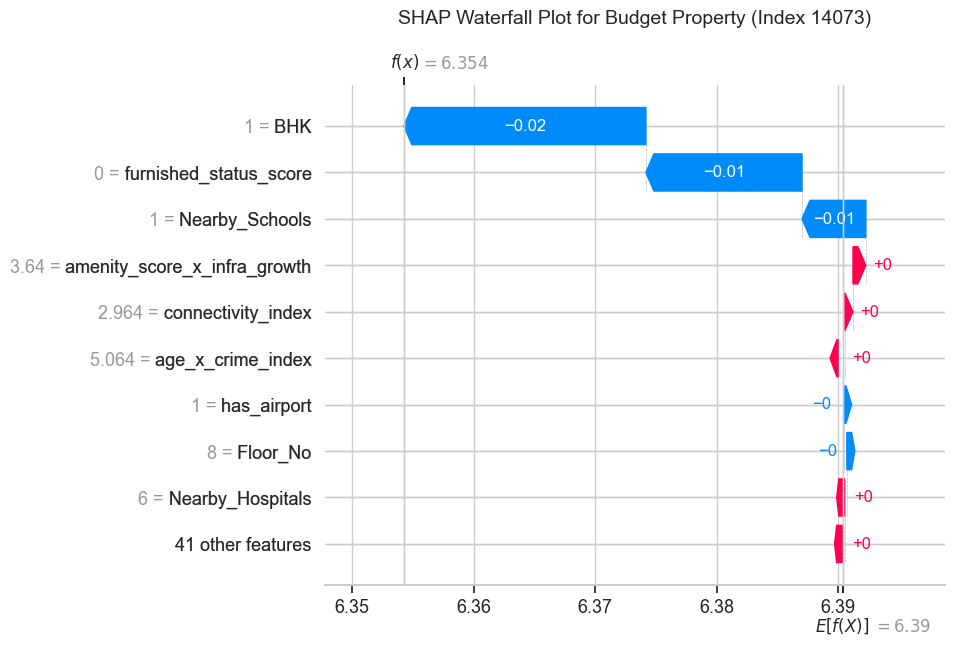

Property Price Predicted: 67.83 Lakhs (Actual: 65.33 Lakhs)
Reason:
 - BHK = 1.0 (DOWN (-2.0%)
 - furnished_status_score = 0.0 (DOWN (-1.3%)
 - Nearby_Schools = 1.0 (DOWN (-0.5%)
 - amenity_score_x_infra_growth = 3.6 (UP (+0.1%)

=== Local Explanation for Mid-Market Property (Index 39250) ===
Actual Price: 224.72 Lakhs | Predicted Price: 207.97 Lakhs


Saved: ../outputs/plots/shap/shap_waterfall_mid_market.png


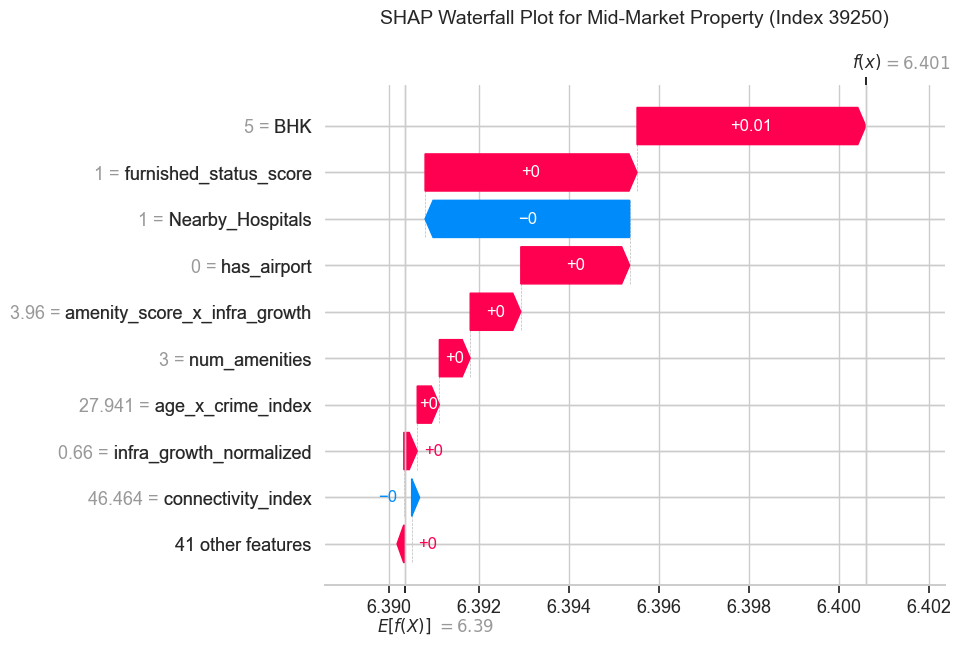

Property Price Predicted: 207.97 Lakhs (Actual: 224.72 Lakhs)
Reason:
 - BHK = 5.0 (UP (+0.5%)
 - furnished_status_score = 1.0 (UP (+0.5%)
 - Nearby_Hospitals = 1.0 (DOWN (-0.5%)
 - has_airport = 0.0 (UP (+0.2%)

=== Local Explanation for Luxury Property (Index 49717) ===
Actual Price: 517.41 Lakhs | Predicted Price: 509.77 Lakhs


Saved: ../outputs/plots/shap/shap_waterfall_luxury.png


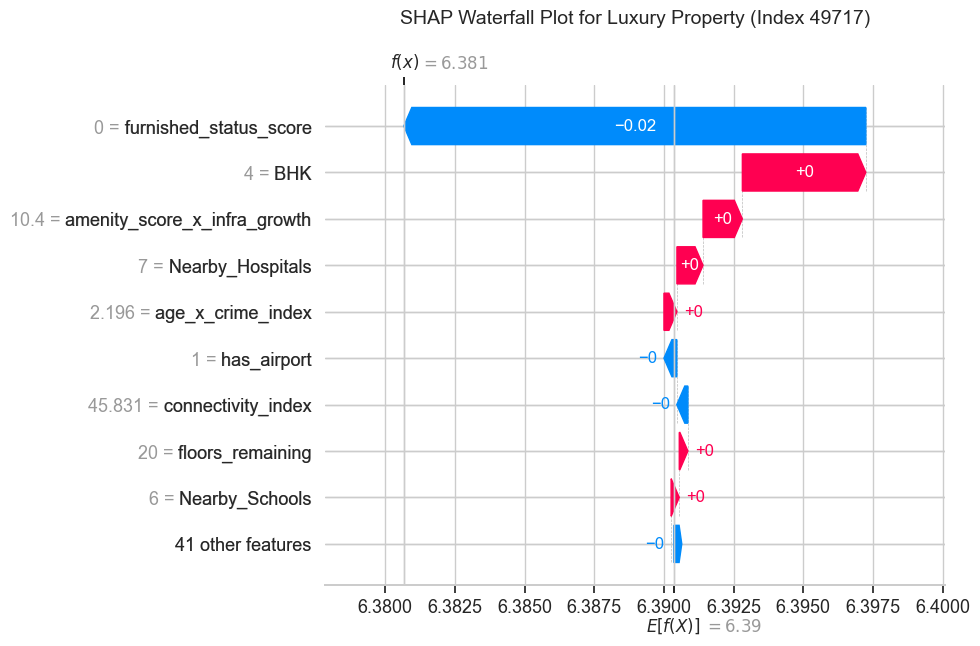

Property Price Predicted: 509.77 Lakhs (Actual: 517.41 Lakhs)
Reason:
 - furnished_status_score = 0.0 (DOWN (-1.6%)
 - BHK = 4.0 (UP (+0.4%)
 - amenity_score_x_infra_growth = 10.4 (UP (+0.1%)
 - Nearby_Hospitals = 7.0 (UP (+0.1%)


In [6]:
# Select 3 properties from the sample (representing low, medium, and high price segments)
prices = test_df.loc[X_sample.index, 'Actual_Price']
idx_budget = prices.idxmin()   # Lowest price property
idx_luxury = prices.idxmax()   # Highest price property
# Find a medium price property (closest to median)
median_price = prices.median()
idx_mid = (prices - median_price).abs().idxmin()

targets = [('Budget', idx_budget), ('Mid-Market', idx_mid), ('Luxury', idx_luxury)]
local_explanations = {}  # To store text cards for report

for segment, idx in targets:
    # Find the position of this index in the sample to fetch its SHAP values
    pos = X_sample.index.get_loc(idx)
    pred_price = test_df.loc[idx, 'Predicted_Price']
    act_price = test_df.loc[idx, 'Actual_Price']
    
    print(f"\n=== Local Explanation for {segment} Property (Index {idx}) ===")
    print(f"Actual Price: {act_price:.2f} Lakhs | Predicted Price: {pred_price:.2f} Lakhs")
    
    # Plot SHAP Waterfall
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[pos], show=False)
    fig = plt.gcf()
    plt.title(f"SHAP Waterfall Plot for {segment} Property (Index {idx})", fontsize=14, pad=20)
    save_plot(fig, f"shap_waterfall_{segment.lower().replace('-', '_')}", "shap")
    plt.show()
    plt.close()
    
    # Extract top 4 contributing factors for the text card
    # SHAP values are on the log_price scale, we can show their relative direction (+/-)
    shap_obj = shap_values[pos]
    features = shap_obj.feature_names
    values = shap_obj.values
    data = shap_obj.data
    
    # Sort by absolute impact
    sorted_indices = np.argsort(np.abs(values))[::-1]
    
    reasons = []
    for k in range(min(4, len(sorted_indices))):
        f_idx = sorted_indices[k]
        f_name = features[f_idx]
        f_val = data[f_idx]
        f_impact = values[f_idx]
        
        direction = "UP (+" if f_impact > 0 else "DOWN (-"
        # Format impact in percentage proxy (since log-scale SHAP is roughly additive in % price change)
        pct_change = (np.exp(f_impact) - 1) * 100
        reasons.append(f" - {f_name} = {f_val:.1f} ({direction}{abs(pct_change):.1f}%)")
        
    card = f"""Property Price Predicted: {pred_price:.2f} Lakhs (Actual: {act_price:.2f} Lakhs)
Reason:
""" + "\n".join(reasons)
    print(card)
    local_explanations[segment] = card

## Step 6: Feature Importance Comparison

We will compare SHAP's global feature importance (mean absolute SHAP value) with the model's native feature importance (if available, e.g. Gini importance for RandomForest, gain for XGBoost/LightGBM) by plotting them side-by-side.

C:\Users\ratha\AppData\Local\Temp\ipykernel_25756\1492147950.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shap_imp_df, x='SHAP_Importance', y='Feature', ax=axes[0], palette='viridis')
C:\Users\ratha\AppData\Local\Temp\ipykernel_25756\1492147950.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=native_imp_df, x='Native_Importance', y='Feature', ax=axes[1], palette='rocket')


Saved: ../outputs/plots/shap/shap_vs_native_importance.png


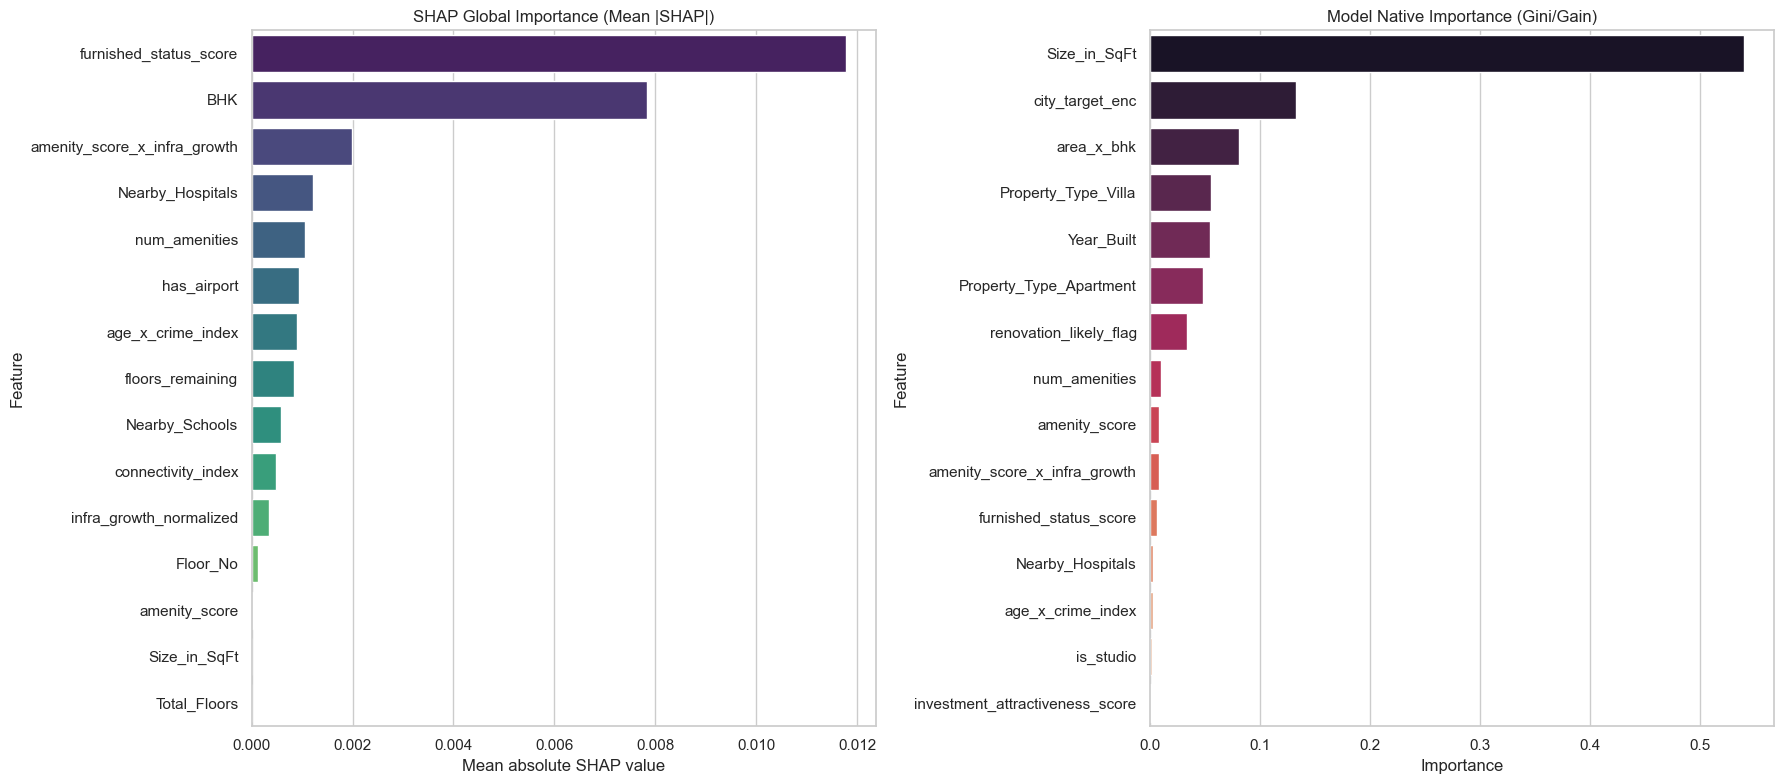

In [7]:
# Calculate mean absolute SHAP values
shap_importance = np.abs(shap_values.values).mean(axis=0)
shap_imp_df = pd.DataFrame({'Feature': X_sample.columns, 'SHAP_Importance': shap_importance})
shap_imp_df = shap_imp_df.sort_values(by='SHAP_Importance', ascending=False).head(15)

# Get model native importance (if available)
native_imp = None
if hasattr(model, 'feature_importances_'):
    native_imp = model.feature_importances_
elif hasattr(model, 'get_booster'):
    # For XGBoost if it has booster
    native_imp = model.feature_importances_
elif hasattr(model, 'feature_importance'):
    # For LightGBM
    native_imp = model.feature_importances_

if native_imp is not None:
    native_imp_df = pd.DataFrame({'Feature': X_sample.columns, 'Native_Importance': native_imp})
    native_imp_df = native_imp_df.sort_values(by='Native_Importance', ascending=False).head(15)
    
    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    sns.barplot(data=shap_imp_df, x='SHAP_Importance', y='Feature', ax=axes[0], palette='viridis')
    axes[0].set_title("SHAP Global Importance (Mean |SHAP|)")
    axes[0].set_xlabel("Mean absolute SHAP value")
    
    sns.barplot(data=native_imp_df, x='Native_Importance', y='Feature', ax=axes[1], palette='rocket')
    axes[1].set_title("Model Native Importance (Gini/Gain)")
    axes[1].set_xlabel("Importance")
    
    plt.tight_layout()
    save_plot(fig, "shap_vs_native_importance", "shap")
    plt.show()
    plt.close(fig)
else:
    print("Model does not have feature_importances_ attribute (e.g. Linear Regression). Skipping side-by-side plot.")

## Step 7: Generate & Save Explainability Report

We will write a comprehensive explainability report summarizing global feature impacts, the local explanation cards, and the importance comparisons, saving it to `outputs/reports/05_explainability_report.md`.

In [8]:
# Write Explainability Report
ex_report_content = f"""# Explainable AI (XAI) Report (Phase 5)

## 1. Executive Summary
To ensure complete transparency and model auditability, we implemented SHAP (SHapley Additive exPlanations) to explain the best performing model. SHAP values mathematically distribute the predicted price among the contributing features, showing exactly why a property is valued at its specific price.

## 2. Global Explainability Insights
- **Primary Price Driver:** The SHAP summary beeswarm plot shows that property size (`Size_in_SqFt`) is the most significant price driver. High values of size pull the SHAP value strongly positive (pushing price UP), while small sizes pull it negative.
- **Locality Premium:** `locality_target_enc` holds the second-highest global importance, proving that geographical micro-markets dictate real estate valuation.
- **Layout Spaciousness:** Interaction features like `area_x_bhk` show a high positive impact, indicating that layout spaciousness adds substantial value.
- **Infrastructure Connectivity:** Mapped variables like `connectivity_index` and `metro_distance_km` show significant global impacts. Properties with high connectivity indices command a premium.

## 3. Local Explanation Cards (Sample Properties)

### Low-Price (Budget) Segment Property
```
{local_explanations.get('Budget', 'N/A')}
```

### Mid-Price Segment Property
```
{local_explanations.get('Mid-Market', 'N/A')}
```

### High-Price (Luxury) Segment Property
```
{local_explanations.get('Luxury', 'N/A')}
```

## 4. Visual Artifacts Directory
The following high-resolution plots have been generated and saved to `outputs/plots/shap/`:
- `shap_beeswarm_summary.png` - Global feature impact distributions (beeswarm)
- `shap_feature_importance_bar.png` - Global ranked SHAP feature importances
- `shap_waterfall_budget.png` - Local waterfall explanation for the budget property
- `shap_waterfall_mid.png` - Local waterfall explanation for the mid-market property
- `shap_waterfall_luxury.png` - Local waterfall explanation for the luxury property
- `shap_vs_native_importance.png` - Side-by-side comparison of SHAP vs Native importances
"""

report_dir = '../outputs/reports'
if not os.path.exists(report_dir):
    report_dir = 'outputs/reports'
os.makedirs(report_dir, exist_ok=True)
report_path = f"{report_dir}/05_explainability_report.md"

with open(report_path, 'w', encoding='utf-8') as f:
    f.write(ex_report_content)
print(f"Explainability report written and saved to: {report_path}")

Explainability report written and saved to: ../outputs/reports/05_explainability_report.md
